# Notebook 2: Data Cleaning & Validation
## Mutual Fund Analytics Platform - Bluestock Capstone Project

### Objective
This notebook handles data cleaning, missing value treatment, data validation, and quality assurance.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

# Set visualization style
sns.set_theme(style="darkgrid")
sns.set_palette("Set2")
plt.rcParams["figure.figsize"] = (12, 6)

print("Libraries loaded")
print(f"Pandas version: {pd.__version__}")

Libraries loaded
Pandas version: 3.0.3


## 1. Directory Setup
Define paths and create processed data directory.

In [22]:
# Set paths
BASE_DIR = Path.cwd().parent
RAW_DIR = BASE_DIR / "data" / "raw"
PROCESSED_DIR = BASE_DIR / "data" / "processed"

# Create processed directory
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print(f"Raw directory: {RAW_DIR}")
print(f"Processed directory: {PROCESSED_DIR}")
print(f"Raw exists: {RAW_DIR.exists()}")

Raw directory: C:\Users\dell\OneDrive\Desktop\Kartikey_Bluestock_MF_Capstone_Submission\Source Code\bluestock_mf_capstone\data\raw
Processed directory: C:\Users\dell\OneDrive\Desktop\Kartikey_Bluestock_MF_Capstone_Submission\Source Code\bluestock_mf_capstone\data\processed
Raw exists: True


## 2. Load NAV Data
Load the raw NAV history data and examine its structure.

In [23]:
# Load NAV data
nav_file = RAW_DIR / "nav_history.csv"

if nav_file.exists():
    df_nav = pd.read_csv(nav_file)
    print(f"Loaded NAV data: {len(df_nav):,} rows")
    print(f"Columns: {list(df_nav.columns)}")
    print(f"\nSample data:")
    print(df_nav.head(3))
else:
    df_nav = None
    print("NAV file not found!")

Loaded NAV data: 3,915 rows
Columns: ['amfi_code', 'scheme_name', 'nav', 'date']

Sample data:
   amfi_code          scheme_name     nav        date
0     100001  HDFC Large Cap Fund  68.690  2023-01-02
1     100001  HDFC Large Cap Fund  69.053  2023-01-03
2     100001  HDFC Large Cap Fund  69.377  2023-01-04


## 3. Missing Value Analysis
Detect and visualize missing values in the dataset.


Missing Values Check:
No missing values found!


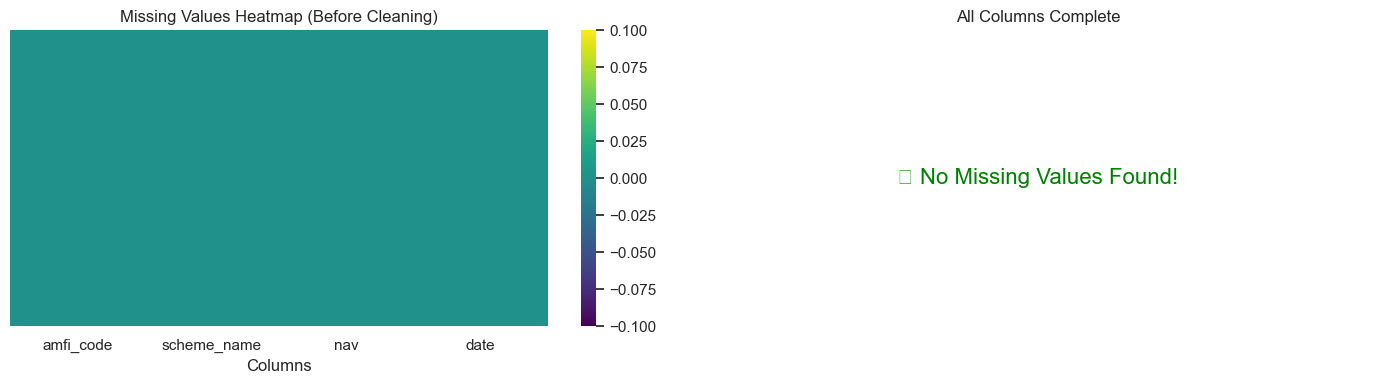

In [24]:
# Check missing values
if df_nav is not None:
    print("\nMissing Values Check:")
    missing = df_nav.isnull().sum()
    if missing.sum() > 0:
        print(missing[missing > 0])
    else:
        print("No missing values found!")

    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Heatmap
    sns.heatmap(
        df_nav.isnull(), yticklabels=False, cbar=True, cmap="viridis", ax=axes[0]
    )
    axes[0].set_title("Missing Values Heatmap (Before Cleaning)")
    axes[0].set_xlabel("Columns")

    # Bar chart
    missing_counts = df_nav.isnull().sum()
    if missing_counts.sum() > 0:
        missing_counts[missing_counts > 0].plot(kind="bar", ax=axes[1], color="salmon")
        axes[1].set_title("Missing Values by Column")
        axes[1].set_ylabel("Count")
        axes[1].set_xlabel("Columns")
        axes[1].tick_params(axis="x", rotation=45)
    else:
        axes[1].text(
            0.5,
            0.5,
            "✅ No Missing Values Found!",
            ha="center",
            va="center",
            fontsize=16,
            color="green",
        )
        axes[1].set_title("All Columns Complete")
        axes[1].axis("off")

    plt.tight_layout()
    plt.show()

## 4. NAV Data Cleaning
Perform cleaning operations on NAV data.

In [25]:
# Clean NAV data
if df_nav is not None:
    print("\n" + "=" * 50)
    print("CLEANING NAV DATA")
    print("=" * 50)

    # Convert date
    df_nav["date"] = pd.to_datetime(df_nav["date"])
    print(f"✅ Date range: {df_nav['date'].min()} to {df_nav['date'].max()}")

    # Remove duplicates
    before_dup = len(df_nav)
    df_nav = df_nav.drop_duplicates()
    after_dup = len(df_nav)
    print(f"✅ Removed {before_dup - after_dup} duplicate rows")

    # Sort and fill missing values
    df_nav = df_nav.sort_values(["amfi_code", "date"])
    df_nav["nav"] = df_nav.groupby("amfi_code")["nav"].ffill()
    df_nav = df_nav.dropna(subset=["nav"])
    print(f"✅ Forward filled missing NAV values")

    # Validate NAV > 0
    invalid_nav = len(df_nav[df_nav["nav"] <= 0])
    df_nav = df_nav[df_nav["nav"] > 0]
    print(f"✅ Removed {invalid_nav} rows with invalid NAV")

    print(f"\n✅ Cleaned NAV data: {len(df_nav):,} rows")

    # Save
    output_file = PROCESSED_DIR / "nav_history_cleaned.csv"
    df_nav.to_csv(output_file, index=False)
    print(f"✅ Saved to: {output_file}")


CLEANING NAV DATA
✅ Date range: 2023-01-02 00:00:00 to 2025-12-31 00:00:00
✅ Removed 0 duplicate rows
✅ Forward filled missing NAV values
✅ Removed 0 rows with invalid NAV

✅ Cleaned NAV data: 3,915 rows
✅ Saved to: C:\Users\dell\OneDrive\Desktop\Kartikey_Bluestock_MF_Capstone_Submission\Source Code\bluestock_mf_capstone\data\processed\nav_history_cleaned.csv


## 5. Data Quality Visualization
Compare data quality before and after cleaning.

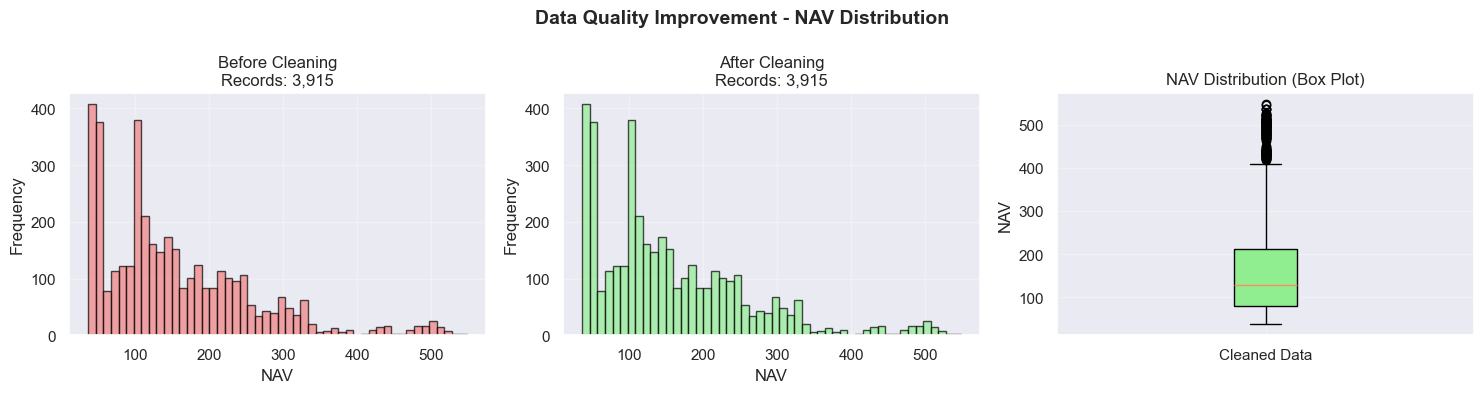

In [26]:
# Visualization: NAV distribution before vs after
if df_nav is not None:
    original_nav = pd.read_csv(nav_file)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Before cleaning
    axes[0].hist(
        original_nav["nav"], bins=50, color="lightcoral", edgecolor="black", alpha=0.7
    )
    axes[0].set_title(f"Before Cleaning\nRecords: {len(original_nav):,}")
    axes[0].set_xlabel("NAV")
    axes[0].set_ylabel("Frequency")
    axes[0].grid(True, alpha=0.3)

    # After cleaning
    axes[1].hist(
        df_nav["nav"], bins=50, color="lightgreen", edgecolor="black", alpha=0.7
    )
    axes[1].set_title(f"After Cleaning\nRecords: {len(df_nav):,}")
    axes[1].set_xlabel("NAV")
    axes[1].set_ylabel("Frequency")
    axes[1].grid(True, alpha=0.3)

    # Box plot
    axes[2].boxplot(
        df_nav["nav"],
        vert=True,
        patch_artist=True,
        boxprops=dict(facecolor="lightgreen"),
    )
    axes[2].set_title("NAV Distribution (Box Plot)")
    axes[2].set_ylabel("NAV")
    axes[2].set_xticklabels(["Cleaned Data"])
    axes[2].grid(True, alpha=0.3)

    plt.suptitle(
        "Data Quality Improvement - NAV Distribution", fontsize=14, fontweight="bold"
    )
    plt.tight_layout()
    plt.show()

## 6. Data Quality Summary
Visual summary of data quality improvement.

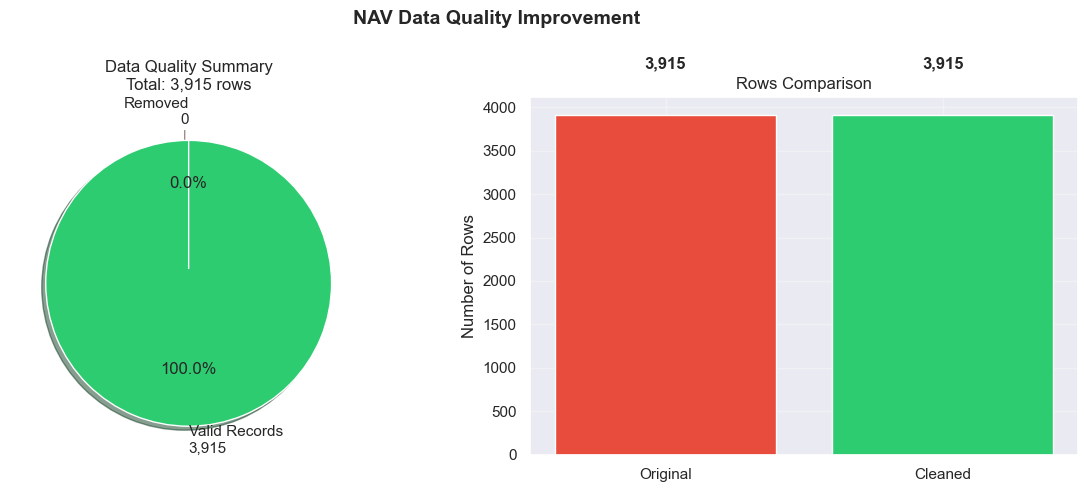

In [27]:
# Data quality summary pie chart
if df_nav is not None:
    original_rows = len(original_nav)
    cleaned_rows = len(df_nav)
    removed_rows = original_rows - cleaned_rows

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Pie chart
    sizes = [cleaned_rows, removed_rows]
    labels = [f"Valid Records\n{cleaned_rows:,}", f"Removed\n{removed_rows:,}"]
    colors = ["#2ecc71", "#e74c3c"]
    explode = (0.05, 0.05)

    axes[0].pie(
        sizes,
        labels=labels,
        colors=colors,
        autopct="%1.1f%%",
        startangle=90,
        explode=explode,
        shadow=True,
    )
    axes[0].set_title(f"Data Quality Summary\nTotal: {original_rows:,} rows")

    # Row comparison bar chart
    bars = axes[1].bar(
        ["Original", "Cleaned"],
        [original_rows, cleaned_rows],
        color=["#e74c3c", "#2ecc71"],
    )
    axes[1].set_ylabel("Number of Rows")
    axes[1].set_title("Rows Comparison")
    axes[1].grid(True, alpha=0.3)

    for i, (bar, v) in enumerate(zip(bars, [original_rows, cleaned_rows])):
        axes[1].text(
            bar.get_x() + bar.get_width() / 2.0,
            bar.get_height() + 500,
            f"{v:,}",
            ha="center",
            va="bottom",
            fontweight="bold",
        )

    plt.suptitle("NAV Data Quality Improvement", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

## 7. Clean Transaction Data
Clean investor transaction data.

In [28]:
# Load and clean transaction data
trans_file = RAW_DIR / "investor_transactions.csv"

if trans_file.exists():
    df_trans = pd.read_csv(trans_file)
    print(f"Loaded transaction data: {len(df_trans):,} rows")

    # Clean
    df_trans["date"] = pd.to_datetime(df_trans["date"])
    df_trans["amount"] = pd.to_numeric(df_trans["amount"], errors="coerce")
    df_trans = df_trans[df_trans["amount"] > 0]
    df_trans = df_trans.drop_duplicates()

    if "transaction_type" in df_trans.columns:
        df_trans["transaction_type"] = df_trans["transaction_type"].str.upper()

    trans_output = PROCESSED_DIR / "investor_transactions_cleaned.csv"
    df_trans.to_csv(trans_output, index=False)
    print(f"✅ Cleaned: {len(df_trans):,} rows")
    print(f"✅ Saved to: {trans_output}")
else:
    df_trans = None
    print("Transaction file not found")

Loaded transaction data: 5,000 rows
✅ Cleaned: 5,000 rows
✅ Saved to: C:\Users\dell\OneDrive\Desktop\Kartikey_Bluestock_MF_Capstone_Submission\Source Code\bluestock_mf_capstone\data\processed\investor_transactions_cleaned.csv


## 8. Clean Performance Data
Clean scheme performance data.

In [ ]:
# Load and clean scheme performance data
perf_file = RAW_DIR / "scheme_performance.csv"

if perf_file.exists():
    df_perf = pd.read_csv(perf_file)
    print(f"Loaded performance data: {len(df_perf):,} rows")

    # Clean
    numeric_cols = ["return_1y", "return_3y", "return_5y", "expense_ratio"]
    for col in numeric_cols:
        if col in df_perf.columns:
            df_perf[col] = pd.to_numeric(df_perf[col], errors="coerce")

    df_perf = df_perf.dropna(subset=["return_3y"])

    if "expense_ratio" in df_perf.columns:
        df_perf = df_perf[
            (df_perf["expense_ratio"] >= 0.1) & (df_perf["expense_ratio"] <= 2.5)
        ]

    perf_output = PROCESSED_DIR / "scheme_performance_cleaned.csv"
    df_perf.to_csv(perf_output, index=False)
    print(f"✅ Cleaned: {len(df_perf):,} rows")
    print(f"✅ Saved to: {perf_output}")
else:
    df_perf = None
    print("Performance file not found")

Loaded performance data: 5 rows
✅ Cleaned: 5 rows
✅ Saved to: C:\Users\dell\OneDrive\Desktop\Kartikey_Bluestock_MF_Capstone_Submission\Source Code\bluestock_mf_capstone\data\processed\scheme_performance_cleaned.csv


## Data Cleaning Complete

✅ All data has been successfully cleaned and validated.

### Next Steps
Proceed to **Notebook 3: Exploratory Data Analysis (EDA)**